# FlexiTokens checkpoint inspection and tokenization analysis

This notebook builds on `inspect_fxt_model_clean.ipynb` to load the supplied FlexiTokens checkpoint, inspect learned boundaries, compare FlexiTokens with the repository's 50k BPE tokenizer, and measure multilingual compression on aligned examples and FLORES.

For a fresh Google Colab runtime, select a GPU and run the notebook from top to bottom. The setup cell clones the repository, downloads the 1.33 GB archive from Google Drive, safely extracts it, and sets `MODEL_PATH`.

## 1. Colab and checkpoint setup

The checkpoint directory used on Colab is:

```text
/content/flexitokens/model_ckpts/_2025-05-03_14-43-31
```

The setup is idempotent: rerunning it skips the clone, download, and extraction when their outputs are already present.

In [3]:
from pathlib import Path
import os
import subprocess
import sys
import tarfile

DRIVE_FILE_ID = "1BOX8jVlXht9CTDXBFzW9rU6AROJabJZF"
EXPECTED_ARCHIVE_BYTES = 1_329_730_324
CHECKPOINT_DIRNAME = "_2025-05-03_14-43-31"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_ROOT = Path("/content/flexitokens")
    if not (REPO_ROOT / "src").is_dir():
        subprocess.run(
            ["git", "clone", "https://github.com/skai-research/flexitokens.git", str(REPO_ROOT)],
            check=True,
        )
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "transformers==4.39.3", "safetensors==0.5.3", "datasets==3.6.0",
        "pandas", "matplotlib", "seaborn", "gdown",
    ])
else:
    candidates = [Path.cwd(), Path.cwd() / "flexitokens"]
    REPO_ROOT = next((path.resolve() for path in candidates if (path / "src").is_dir()), None)
    if REPO_ROOT is None:
        raise FileNotFoundError("Run this notebook from the cloned flexitokens repository.")

CHECKPOINTS_DIR = REPO_ROOT / "model_ckpts"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ARCHIVE = CHECKPOINTS_DIR / "model.tar.xz"
MODEL_PATH = CHECKPOINTS_DIR / CHECKPOINT_DIRNAME

if IN_COLAB and not (MODEL_PATH / "model.pth").is_file():
    import gdown
    if not MODEL_ARCHIVE.is_file() or MODEL_ARCHIVE.stat().st_size != EXPECTED_ARCHIVE_BYTES:
        gdown.download(id=DRIVE_FILE_ID, output=str(MODEL_ARCHIVE), quiet=False, resume=True)
    actual_bytes = MODEL_ARCHIVE.stat().st_size
    if actual_bytes != EXPECTED_ARCHIVE_BYTES:
        raise IOError(f"Incomplete archive: expected {EXPECTED_ARCHIVE_BYTES} bytes, got {actual_bytes}.")

if not (MODEL_PATH / "model.pth").is_file():
    if not MODEL_ARCHIVE.is_file():
        raise FileNotFoundError(f"Checkpoint archive not found: {MODEL_ARCHIVE}")
    destination = CHECKPOINTS_DIR.resolve()
    with tarfile.open(MODEL_ARCHIVE, mode="r:xz") as archive:
        for member in archive.getmembers():
            target = (destination / member.name).resolve()
            if destination not in target.parents and target != destination:
                raise RuntimeError(f"Unsafe archive member: {member.name}")
            if member.issym() or member.islnk():
                raise RuntimeError(f"Archive links are not allowed: {member.name}")
        archive.extractall(destination)

required_files = ["config.json", "model.pth", "tokenizer_config.json"]
missing = [name for name in required_files if not (MODEL_PATH / name).is_file()]
if missing:
    raise FileNotFoundError(f"Checkpoint extraction is incomplete; missing: {missing}")

os.chdir(REPO_ROOT)
print(f"Repository: {REPO_ROOT}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"Checkpoint ready: {(MODEL_PATH / 'model.pth').stat().st_size / 2**30:.2f} GiB of weights")

Downloading...
From (original): https://drive.google.com/uc?id=1BOX8jVlXht9CTDXBFzW9rU6AROJabJZF
From (redirected): https://drive.google.com/uc?id=1BOX8jVlXht9CTDXBFzW9rU6AROJabJZF&confirm=t&uuid=7201eb49-5a4d-4bff-99b9-c5b893633ccc
To: /content/flexitokens/model_ckpts/model.tar.xz
100%|██████████| 1.33G/1.33G [00:14<00:00, 90.1MB/s]
/tmp/ipykernel_724/2593214393.py:54: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(destination)


Repository: /content/flexitokens
MODEL_PATH: /content/flexitokens/model_ckpts/_2025-05-03_14-43-31
Checkpoint ready: 1.40 GiB of weights


## 2. Load the model and local tokenizer

The checkpoint includes ByT5 tokenizer metadata, so no separate tokenizer download is needed. The loader below constructs the repository's `FxTTransformerLM` with named configuration arguments and loads only the model state from `model.pth`.

In [4]:
import gc
import inspect
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import HTML, display
from transformers import AutoTokenizer

from src.model.fxt import FxTTransformerLM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
print(f"Device: {DEVICE}")

Device: cuda


In [5]:
def _constructor_kwargs(model_class, config):
    """Select the checkpoint fields accepted by FxTTransformerLM.__init__."""
    parameters = inspect.signature(model_class.__init__).parameters
    required = [
        name for name, parameter in parameters.items()
        if name != "self"
        and parameter.default is inspect.Parameter.empty
        and parameter.kind in (parameter.POSITIONAL_OR_KEYWORD, parameter.KEYWORD_ONLY)
    ]
    missing = [name for name in required if name not in config]
    if missing:
        raise KeyError(f"Checkpoint config is missing constructor fields: {missing}")
    return {name: config[name] for name in parameters if name != "self" and name in config}


def _safe_torch_load(path):
    kwargs = {"map_location": "cpu"}
    load_parameters = inspect.signature(torch.load).parameters
    if "weights_only" in load_parameters:
        kwargs["weights_only"] = True
    if "mmap" in load_parameters:
        kwargs["mmap"] = True
    return torch.load(path, **kwargs)


def load_fxt_model(model_path, device=DEVICE):
    model_path = Path(model_path)
    with (model_path / "config.json").open() as handle:
        config = json.load(handle)

    config.setdefault("ignore_index", -100)
    config.setdefault("num_predictors", 1)
    model = FxTTransformerLM(**_constructor_kwargs(FxTTransformerLM, config))

    checkpoint = _safe_torch_load(model_path / "model.pth")
    state_dict = checkpoint.get("model", checkpoint)
    try:
        model.load_state_dict(state_dict, assign=True)
    except TypeError:
        model.load_state_dict(state_dict)
    del state_dict, checkpoint
    gc.collect()

    model.to(device).eval()
    tokenizer = AutoTokenizer.from_pretrained(str(model_path), local_files_only=True)
    return model, tokenizer, config


def language_token_id(config, tokenizer, language):
    if language not in config["language_to_script"]:
        supported = ", ".join(config["language_to_script"])
        raise KeyError(f"Unsupported language {language!r}; choose one of: {supported}")
    script_token = config["language_to_script"][language]
    token_id = tokenizer.convert_tokens_to_ids(script_token)
    if token_id is None or token_id == tokenizer.unk_token_id:
        matches = [int(key) for key, value in config["id_to_script"].items() if value == script_token]
        if not matches:
            raise KeyError(f"No special token ID found for {language!r}")
        token_id = matches[0]
    return int(token_id)


model, tokenizer, config = load_fxt_model(MODEL_PATH)
print(f"Loaded {type(model).__name__}")
print(f"Tokenizer: {type(tokenizer).__name__} ({len(tokenizer)} tokens)")
print({language: language_token_id(config, tokenizer, language) for language in config["language_to_script"]})

Loaded FxTTransformerLM
Tokenizer: ByT5Tokenizer (266 tokens)
{'en': 259, 'es': 260, 'ru': 261, 'uk': 262, 'hi': 263, 'te': 264}


## 3. Inspect learned boundaries for one sentence

The base tokenizer is byte-level. FlexiTokens predicts boundaries over those byte tokens and combines each run into one learned token. Because this checkpoint uses a Gumbel boundary predictor, a fixed seed is used for reproducible inspection.

In [6]:
def boundary_module(model):
    modules = getattr(model, "script_to_bp_layers", None)
    if modules is None or len(modules) == 0:
        raise RuntimeError("This model does not expose a boundary predictor.")
    return next(iter(modules.items()))


def _set_inference_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def inspect_boundary_predictor(text, language="en", seed=42):
    encoded = tokenizer(text, add_special_tokens=False)
    text_token_ids = encoded["input_ids"]
    lang_id = language_token_id(config, tokenizer, language)
    batch = {
        "input_ids": torch.tensor([[lang_id, *text_token_ids]], dtype=torch.long, device=DEVICE),
        "attention_mask": torch.ones((1, len(text_token_ids)), dtype=torch.long, device=DEVICE),
    }
    _set_inference_seed(seed)
    with torch.inference_mode():
        _, stats, _ = model(batch, task="tokenization2")

    predictor_name, predictor = boundary_module(model)
    hard = stats["hard_boundaries"][0, :len(text_token_ids)].detach().float().cpu()
    soft = predictor.soft_boundaries[0, :len(text_token_ids)].detach().float().cpu()
    rows = []
    for position, token_id in enumerate(text_token_ids):
        rows.append({
            "position": position,
            "byte_token_id": token_id,
            "byte_piece": tokenizer.convert_ids_to_tokens(token_id),
            "boundary_sample": float(soft[position]),
            "hard_boundary": int(hard[position] >= 0.5),
        })
    return {
        "text": text,
        "language": language,
        "predictor": predictor_name,
        "token_ids": text_token_ids,
        "soft": soft.tolist(),
        "hard": hard.tolist(),
        "table": pd.DataFrame(rows),
    }


def boundary_segments(inspection):
    segments, current_ids, positions = [], [], []
    token_ids = inspection["token_ids"]
    for position, token_id in enumerate(token_ids):
        current_ids.append(token_id)
        positions.append(position)
        is_boundary = inspection["hard"][position] >= 0.5
        is_last = position == len(token_ids) - 1
        if is_boundary or is_last:
            segments.append({
                "segment_id": len(segments),
                "span": f"{positions[0]}..{positions[-1]}",
                "base_byte_tokens": len(current_ids),
                "text": tokenizer.decode(current_ids, skip_special_tokens=False),
                "end_boundary_sample": inspection["soft"][position],
                "predicted_boundary": bool(is_boundary),
            })
            current_ids, positions = [], []
    return segments


def show_boundary_overlay(inspection, show_values=True):
    import html
    spans = []
    for segment in boundary_segments(inspection):
        probability = segment["end_boundary_sample"]
        label = f"<sup style='color:#4b5563;margin-left:3px'>{probability:.2f}</sup>" if show_values else ""
        title = (
            f"FXT token {segment['segment_id']} | base span {segment['span']} | "
            f"{segment['base_byte_tokens']} byte tokens | boundary sample {probability:.3f}"
        )
        spans.append(
            "<span title='{title}' style='display:inline-block;margin:2px;padding:3px 5px;"
            "border:1px solid #86efac;border-bottom:3px solid #15803d;border-radius:4px;"
            "background:#dcfce7;font-family:ui-monospace,SFMono-Regular,Menlo,monospace'>"
            "{text}{label}</span>".format(
                title=html.escape(title), text=html.escape(segment["text"]), label=label
            )
        )
    display(HTML("".join(spans)))


inspection = inspect_boundary_predictor("I love watching movies", language="en", seed=42)
show_boundary_overlay(inspection)
display(pd.DataFrame(boundary_segments(inspection)))
display(inspection["table"])

,segment_id,span,base_byte_tokens,text,end_boundary_sample,predicted_boundary
0,0,0..1,2,I,9.999987e-01,True
1,1,2..6,5,love,9.999999e-01,True
2,2,7..9,3,wat,9.980566e-01,True
3,3,10..14,5,ching,9.999999e-01,True
4,4,15..19,5,movies,4.829027e-13,False


,position,byte_token_id,byte_piece,boundary_sample,hard_boundary
0,0,76,I,2.551219e-02,0
1,1,35,,9.999987e-01,1
2,2,111,l,2.470972e-11,0
3,3,114,o,2.506968e-17,0
4,4,121,v,4.874652e-16,0
5,5,104,e,4.035616e-11,0
6,6,35,,9.999999e-01,1
7,7,122,w,7.054683e-11,0
8,8,100,a,1.653162e-14,0
9,9,119,t,9.980566e-01,1


## 4. Compare FlexiTokens with 50k BPE

For every sentence, the analysis reports:

- byte tokens: the number of ByT5 base tokens before learned grouping;
- FlexiTokens: the number of predicted groups after forcing the final byte into a segment;
- BPE tokens: the count from `data/bpe_tokenizer_50000`;
- compression: byte tokens divided by FlexiTokens;
- reduction vs BPE: the percentage change in sequence length relative to BPE.

,language,text,utf8_bytes,base_byte_tokens,fxt_tokens,bpe_tokens,bytes_per_fxt_token,fxt_reduction_vs_bpe_pct
0,en,I love watching movies.,23,21,5,5,4.200000,0.000000
1,es,Me encanta ver películas.,26,25,8,5,3.125000,-60.000000
2,ru,Я люблю смотреть фильмы.,44,44,6,5,7.333333,-20.000000
3,uk,Я люблю дивитися фільми.,44,44,6,6,7.333333,0.000000
4,hi,मुझे फ़िल्में देखना पसंद है।,76,76,9,15,8.444444,40.000000
5,te,నాకు సినిమాలు చూడటం ఇష్టం.,70,70,8,14,8.750000,42.857143


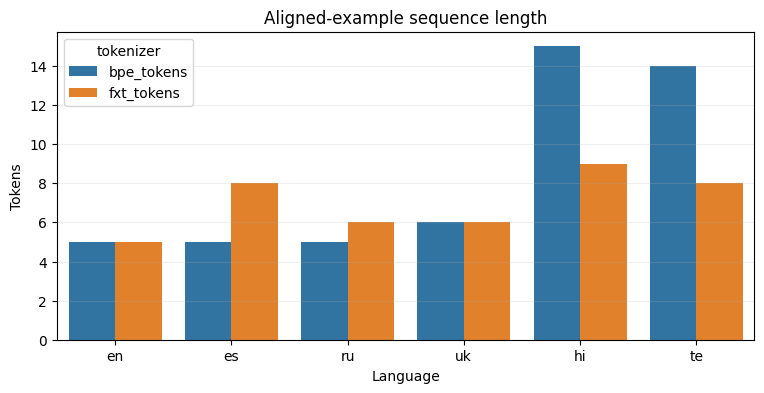

In [7]:
BPE_TOKENIZER_PATH = REPO_ROOT / "data" / "bpe_tokenizer_50000"
bpe_tokenizer = AutoTokenizer.from_pretrained(str(BPE_TOKENIZER_PATH), local_files_only=True)


def _boundary_batch(texts, language, seed=42):
    encoded = tokenizer(
        list(texts),
        add_special_tokens=False,
        padding=True,
        truncation=True,
        max_length=int(config["seq_len"]),
        return_tensors="pt",
    )
    attention_mask = encoded["attention_mask"]
    language_column = torch.full(
        (len(texts), 1), language_token_id(config, tokenizer, language), dtype=torch.long
    )
    batch = {
        "input_ids": torch.cat([language_column, encoded["input_ids"]], dim=1).to(DEVICE),
        "attention_mask": attention_mask.to(DEVICE),
    }
    _set_inference_seed(seed)
    with torch.inference_mode():
        _, stats, _ = model(batch, task="tokenization2")
    hard = stats["hard_boundaries"].detach().float().cpu()
    return attention_mask.sum(dim=1).tolist(), hard


def analyze_tokenization(texts, language, batch_size=8, seed=42):
    rows = []
    texts = list(texts)
    for batch_start in range(0, len(texts), batch_size):
        text_batch = texts[batch_start:batch_start + batch_size]
        lengths, hard = _boundary_batch(text_batch, language, seed=seed + batch_start)
        for row_index, (text, base_tokens) in enumerate(zip(text_batch, lengths)):
            base_tokens = int(base_tokens)
            hard_row = hard[row_index, :base_tokens] >= 0.5
            predicted_boundaries = int(hard_row.sum().item())
            final_is_boundary = bool(hard_row[-1].item()) if base_tokens else False
            fxt_tokens = predicted_boundaries + int(base_tokens > 0 and not final_is_boundary)
            bpe_tokens = len(bpe_tokenizer(text, add_special_tokens=False)["input_ids"])
            rows.append({
                "language": language,
                "text": text,
                "utf8_bytes": len(text.encode("utf-8")),
                "base_byte_tokens": base_tokens,
                "fxt_tokens": fxt_tokens,
                "bpe_tokens": bpe_tokens,
                "bytes_per_fxt_token": base_tokens / fxt_tokens if fxt_tokens else math.nan,
                "fxt_reduction_vs_bpe_pct": (
                    100 * (bpe_tokens - fxt_tokens) / bpe_tokens if bpe_tokens else math.nan
                ),
            })
    return pd.DataFrame(rows)


ALIGNED_EXAMPLES = {
    "en": "I love watching movies.",
    "es": "Me encanta ver películas.",
    "ru": "Я люблю смотреть фильмы.",
    "uk": "Я люблю дивитися фільми.",
    "hi": "मुझे फ़िल्में देखना पसंद है।",
    "te": "నాకు సినిమాలు చూడటం ఇష్టం.",
}

example_results = pd.concat(
    [analyze_tokenization([text], language, batch_size=1) for language, text in ALIGNED_EXAMPLES.items()],
    ignore_index=True,
)
display(example_results)

plot_data = example_results.melt(
    id_vars="language",
    value_vars=["bpe_tokens", "fxt_tokens"],
    var_name="tokenizer",
    value_name="tokens",
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_data, x="language", y="tokens", hue="tokenizer", ax=ax)
ax.set(title="Aligned-example sequence length", xlabel="Language", ylabel="Tokens")
ax.grid(axis="y", alpha=0.2)
plt.show()

## 5. FLORES multilingual analysis

This section samples aligned `devtest` sentences from the six languages represented in the checkpoint. It uses the public, consolidated Parquet mirror [`yash9439/flores200`](https://huggingface.co/datasets/yash9439/flores200), so a fresh Colab runtime does not need Hugging Face authentication. Set `RUN_FLORES = False` when you only want the quick qualitative example. Increasing `FLORES_SAMPLE_SIZE` improves stability but increases GPU time.

In [8]:
RUN_FLORES = True
FLORES_SAMPLE_SIZE = 100
FLORES_BATCH_SIZE = 8

FLORES_COLUMNS = {
    "en": "eng_Latn",
    "es": "spa_Latn",
    "ru": "rus_Cyrl",
    "uk": "ukr_Cyrl",
    "hi": "hin_Deva",
    "te": "tel_Telu",
}

flores_texts = {}
if RUN_FLORES:
    from datasets import load_dataset

    dataset = load_dataset(
        "yash9439/flores200",
        split=f"devtest[:{FLORES_SAMPLE_SIZE}]",
    )
    for language, column in FLORES_COLUMNS.items():
        flores_texts[language] = list(dataset[column])
        print(f"{language}: {len(flores_texts[language])} sentences")

README.md:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

dev.parquet: reconstructing file:   0%|          |  0.00B / 21.5MB            

dev.parquet: downloading bytes:           |  0.00B            

devtest.parquet: reconstructing file:   0%|          |  0.00B / 22.5MB            

devtest.parquet: downloading bytes:           |  0.00B            

Generating dev split:   0%|          | 0/997 [00:00<?, ? examples/s]

Generating devtest split:   0%|          | 0/1012 [00:00<?, ? examples/s]

en: 100 sentences
es: 100 sentences
ru: 100 sentences
uk: 100 sentences
hi: 100 sentences
te: 100 sentences


,language,sentences,mean_utf8_bytes,mean_bpe_tokens,mean_fxt_tokens,mean_bytes_per_fxt_token,mean_fxt_reduction_vs_bpe_pct
0,en,100,140.04,33.16,41.28,3.287,-25.682
1,es,100,172.75,40.15,42.42,3.884,-7.125
2,hi,100,362.47,71.64,40.19,8.680,42.756
3,ru,100,283.62,38.16,42.45,6.561,-13.703
4,te,100,375.60,73.62,40.13,8.998,44.426
5,uk,100,262.77,37.04,43.04,6.042,-18.346


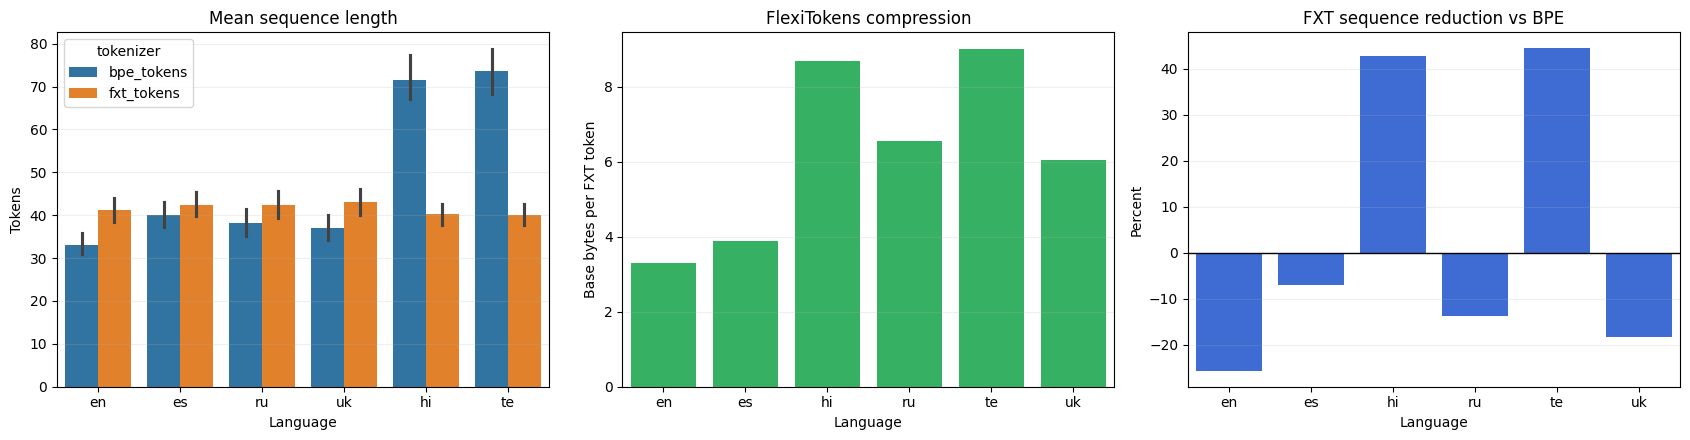

In [9]:
if RUN_FLORES:
    flores_results = pd.concat(
        [
            analyze_tokenization(
                texts,
                language,
                batch_size=FLORES_BATCH_SIZE,
                seed=42,
            )
            for language, texts in flores_texts.items()
        ],
        ignore_index=True,
    )

    flores_summary = (
        flores_results.groupby("language", as_index=False)
        .agg(
            sentences=("text", "size"),
            mean_utf8_bytes=("utf8_bytes", "mean"),
            mean_bpe_tokens=("bpe_tokens", "mean"),
            mean_fxt_tokens=("fxt_tokens", "mean"),
            mean_bytes_per_fxt_token=("bytes_per_fxt_token", "mean"),
            mean_fxt_reduction_vs_bpe_pct=("fxt_reduction_vs_bpe_pct", "mean"),
        )
        .sort_values("language")
    )
    display(flores_summary.round(3))

    token_lengths = flores_results.melt(
        id_vars="language",
        value_vars=["bpe_tokens", "fxt_tokens"],
        var_name="tokenizer",
        value_name="tokens",
    )
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    sns.barplot(data=token_lengths, x="language", y="tokens", hue="tokenizer", ax=axes[0])
    axes[0].set(title="Mean sequence length", xlabel="Language", ylabel="Tokens")

    sns.barplot(
        data=flores_summary,
        x="language",
        y="mean_bytes_per_fxt_token",
        color="#22c55e",
        ax=axes[1],
    )
    axes[1].set(title="FlexiTokens compression", xlabel="Language", ylabel="Base bytes per FXT token")

    sns.barplot(
        data=flores_summary,
        x="language",
        y="mean_fxt_reduction_vs_bpe_pct",
        color="#2563eb",
        ax=axes[2],
    )
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set(title="FXT sequence reduction vs BPE", xlabel="Language", ylabel="Percent")

    for axis in axes:
        axis.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

## Reading the results

- Higher `bytes_per_fxt_token` means stronger compression of the byte-level input.
- Positive `fxt_reduction_vs_bpe_pct` means FlexiTokens produced a shorter sequence than 50k BPE; a negative value means it produced a longer one.
- Compare languages on both sequence length and compression. UTF-8 uses different numbers of bytes across scripts, so raw byte counts alone are not a language-fair tokenization measure.
- This checkpoint uses stochastic Gumbel sampling. The notebook fixes seeds for reproducibility, but a rigorous report should repeat the corpus analysis over several seeds and report mean and variation.